In [1]:
# Import system packages
using Printf
using DelimitedFiles
using Plots
using LaTeXStrings

In [14]:
# Import AGNI
ROOT_DIR = abspath(pwd(),"..","..")
println(ROOT_DIR)
using AGNI

# Disable logging from AGNI module
AGNI.setup_logging("",1)

/home/harrison/Projects/AGNI/


In [3]:
R_earth = 6.371e6
M_earth = 5.972e24
S_earth = 1362.0

1362.0

In [20]:
# Configuration options
instellation    = 5.01*S_earth
mass            = 2.31*M_earth
radius          = 1.304*R_earth
gravity         = 6.67e-11 * mass / radius^2
p_surf          = 1e3
tmp_surf        = 3000.0
s0_fact         = 0.25
zenith_degrees  = 54.74
albedo_b        = 0.0
nlev_centre     = 38
p_top           = 1e-5      # bar

x_H2O = 0.01
mole_fractions  = Dict([
                        ("H2O", x_H2O),
                        ("H2" , 1-x_H2O)
                    ])
thermo          = true
real_gas        = true

phys.species.ENABLE_AQUA = true

albedo_data   = joinpath(ROOT_DIR,"res/surface_albedos/lunarmarebasalt.dat")
spectral_file = joinpath(ROOT_DIR,"res/spectral_files/Dayspring/48/Dayspring.sf")
star_file     = joinpath(ROOT_DIR,"res/stellar_spectra/sun.txt")
output_dir    = joinpath(ROOT_DIR,"out/")

"/home/harrison/Projects/AGNI/out/"

In [17]:
# Create output directory
rm(output_dir,force=true,recursive=true)
mkdir(output_dir);

In [21]:
# Setup atmosphere
atmos = atmosphere.Atmos_t()
atmosphere.setup!(atmos, ROOT_DIR, output_dir,
                        spectral_file,
                        instellation, s0_fact, albedo_b, zenith_degrees,
                        tmp_surf,
                        gravity, radius,
                        nlev_centre, p_surf, p_top,
                        mole_fractions, "",

                        flux_int = 0.0,
                        flag_gcontinuum=true,
                        flag_rayleigh=true,
                        real_gas=real_gas,
                        thermo_functions=thermo,
                        surface_material=albedo_data
                    )
atmosphere.allocate!(atmos, star_file)

[ INFO  ] Setting-up a new atmosphere struct
[ INFO  ] Loading thermodynamic data
[ INFO  ] Inserting stellar spectrum, Rayleigh coefficients
[ INFO  ] Allocating atmosphere with initial composition:
[ INFO  ]       1 H2O      1.00e-02 (EOS_AQUA)
[ INFO  ]       2 H2       9.90e-01 (EOS_CMS19)


true

In [22]:
x_arr = collect(Float64, range(0.95, 0.05, length=4))
nsamps = length(x_arr)
display(nsamps)
display(x_arr)

4

4-element Vector{Float64}:
 0.95
 0.65
 0.35
 0.05

In [ ]:
atm_con_ide = atmosphere.Atmos_t[] # convective, ideal
atm_con_rea = atmosphere.Atmos_t[] # convective, real
@printf("Running convective model for 2*%d samples... \n", nsamps)
for i in 1:nsamps
    @printf("    sample %d/%d \n",i,nsamps)

    # update planet
    x_H2O = x_arr[i]
    println("    x_H2O = $x_H2O")
    fill!(atmos.gas_vmr["H2O"], x_H2O)
    fill!(atmos.gas_vmr["H2"], 1-x_H2O)

    # set ideal
    atmos.gas_dat["H2O"].eos = species.EOS_IDEAL
    atmos.gas_dat["H2"].eos = species.EOS_IDEAL

    # run convective
    println("    con-ide")
    setpt.dry_adiabat!(atmos)
    setpt.saturation!(atmos, "H2O")
    energy.calc_fluxes!(atmos; radiative=true, convective=true)
    diagnostics.calc_observed_rho!(atmos)
    push!(atm_con_ide, deepcopy(atmos))

    # set real gas
    atmos.gas_dat["H2O"].eos = species.EOS_AQUA
    atmos.gas_dat["H2"].eos = species.EOS_CMS19

    # run convective
    println("    con-rea")
    setpt.dry_adiabat!(atmos)
    setpt.saturation!(atmos, "H2O")
    energy.calc_fluxes!(atmos; radiative=true, convective=true)
    diagnostics.calc_observed_rho!(atmos)
    push!(atm_con_rea, deepcopy(atmos))

    @printf("--------------------------------- \n")
end

rtol = 0.1
lins = 0
atm_sol_ide = atmosphere.Atmos_t[] # solved, ideal
atm_sol_rea = atmosphere.Atmos_t[] # solved, real
@printf("Running radiative-convective model for 2*%d samples... \n", nsamps)
setpt.stratosphere!(atmos, 500.0)
for i in 1:nsamps
    @printf("    sample %d/%d \n",i,nsamps)

    # update planet
    x_H2O = x_arr[i]
    println("    x_H2O = $x_H2O")
    fill!(atmos.gas_vmr["H2O"], x_H2O)
    fill!(atmos.gas_vmr["H2"], 1-x_H2O)

    # set ideal
    atmos.gas_dat["H2O"].eos = species.EOS_IDEAL
    atmos.gas_dat["H2"].eos = species.EOS_IDEAL

    # run RCE
    println("    sol-ide")
    solver.solve_energy!(atmos, save_frames=false, ls_method=lins, conv_rtol=rtol, dx_max=100.0)
    diagnostics.calc_observed_rho!(atmos)
    push!(atm_sol_ide, deepcopy(atmos))

    # set real gas
    atmos.gas_dat["H2O"].eos = species.EOS_VDW
    atmos.gas_dat["H2"].eos = species.EOS_CMS19

    # run RCE
    println("    sol-rea")
    solver.solve_energy!(atmos,save_frames=false, ls_method=lins, conv_rtol=rtol, dx_max=50.0)
    diagnostics.calc_observed_rho!(atmos)
    push!(atm_sol_rea, deepcopy(atmos))

    @printf("--------------------------------- \n")
end


println("Done!")

Running convective model for 2*4 samples... 
    sample 1/4 
    x_H2O = 0.95
    con-ide
    con-rea
--------------------------------- 
    sample 2/4 
    x_H2O = 0.65
    con-ide
    con-rea
--------------------------------- 
    sample 3/4 
    x_H2O = 0.35
    con-ide
    con-rea
--------------------------------- 
    sample 4/4 
    x_H2O = 0.05
    con-ide
    con-rea
--------------------------------- 
Running radiative-convective model for 2*4 samples... 
    sample 1/4 
    x_H2O = 0.95
    sol-ide


[ INFO  ]     sol_type = 1,     conv_type = 1
[ INFO  ]     tmp_surf = 3000.00 K
[ INFO  ]     step  |res_med|    cost     flux_OLR   max(x)     max(|dx|)  flags
[ INFO  ]        1  9.469e+01  1.373e+07  1.687e+03  3.000e+03  1.000e+02  Cs-C2
[ INFO  ]        2  2.273e+01  2.792e+06  1.035e+03  3.000e+03  9.003e+01  Cs-C2
[ INFO  ]        3  3.165e+00  5.402e+05  8.768e+02  3.000e+03  6.169e+01  Cs-C2
[ INFO  ]        4  5.387e-01  1.039e+05  8.413e+02  3.000e+03  4.574e+01  Cs-C2
[ INFO  ]        5  1.824e-02  1.973e+04  8.403e+02  3.000e+03  1.759e+01  Cs-C2
[ INFO  ]        6  5.389e-04  3.389e+03  8.407e+02  3.000e+03  2.208e+00  Cs-C2
[ INFO  ]        7  1.139e-05  2.250e+03  8.409e+02  3.000e+03  2.470e-01  Cs-C2
[ INFO  ]        8  6.077e-02  8.590e+03  8.639e+02  3.000e+03  1.000e+02  Cs-C2
[ INFO  ]        9  1.164e-01  1.833e+06  9.010e+02  3.000e+03  1.000e+02  Cs-C2
[ INFO  ]       10  2.213e-01  1.734e+06  9.500e+02  3.000e+03  1.000e+02  Cs-C2
[ INFO  ]       11  5.636e-0

    sol-rea


[ INFO  ]     step  |res_med|    cost     flux_OLR   max(x)     max(|dx|)  flags
[ INFO  ]        1  8.982e-03  3.618e+02  1.633e+03  3.000e+03  3.543e+00  Cs-C2
[ INFO  ]        2  1.040e-06  1.118e+01  1.633e+03  3.000e+03  4.118e-02  Cs-C2
[ INFO  ]     success in 2 steps
[ INFO  ]     total flux at TOA  = +8.63e+02 W m-2     
[ INFO  ]     total flux at BOA  = +8.63e+02 W m-2     
[ INFO  ]     global flux loss   = +1.00e+01 W m-2  (+1.15e+00 %) 
[ INFO  ]     final conv.value   = +1.12e+01 W m-2     
[ INFO  ]     surf temperature   = 3000.000  K        
[ INFO  ]     surf pressure      = 1.000e+03 bar      
[ INFO  ]     sol_type = 1,     conv_type = 1
[ INFO  ]     tmp_surf = 3000.00 K


--------------------------------- 
    sample 2/4 
    x_H2O = 0.65
    sol-ide


...

--------------------------------- 
    sample 4/4 
    x_H2O = 0.05
    sol-ide


[ INFO  ]     step  |res_med|    cost     flux_OLR   max(x)     max(|dx|)  flags
[ INFO  ]        1  1.124e-02  2.713e+02  1.639e+03  3.000e+03  3.632e+00  Cs-C2
[ INFO  ]        2  6.051e-07  1.352e+02  1.639e+03  3.000e+03  4.734e-02  Cs-C2
[ INFO  ]        3  1.163e-07  8.568e+00  1.639e+03  3.000e+03  5.512e-03  Cs-C2
[ INFO  ]     success in 3 steps
[ INFO  ]     total flux at TOA  = +8.69e+02 W m-2     
[ INFO  ]     total flux at BOA  = +8.69e+02 W m-2     
[ INFO  ]     global flux loss   = +7.38e+00 W m-2  (+8.49e-01 %) 
[ INFO  ]     final conv.value   = +8.57e+00 W m-2     
[ INFO  ]     surf temperature   = 3000.000  K        
[ INFO  ]     surf pressure      = 1.000e+03 bar      
[ INFO  ]     sol_type = 1,     conv_type = 1
[ INFO  ]     tmp_surf = 3000.00 K


    sol-rea


[ INFO  ]     step  |res_med|    cost     flux_OLR   max(x)     max(|dx|)  flags
[ INFO  ]        1  8.954e-03  2.717e+02  1.633e+03  3.000e+03  3.666e+00  Cs-C2
[ INFO  ]        2  1.219e-06  5.039e+00  1.633e+03  3.000e+03  3.934e-02  Cs-C2
[ INFO  ]     success in 2 steps
[ INFO  ]     total flux at TOA  = +8.63e+02 W m-2     
[ INFO  ]     total flux at BOA  = +8.63e+02 W m-2     
[ INFO  ]     global flux loss   = +4.86e+00 W m-2  (+5.61e-01 %) 
[ INFO  ]     final conv.value   = +5.04e+00 W m-2     
[ INFO  ]     surf temperature   = 3000.000  K        
[ INFO  ]     surf pressure      = 1.000e+03 bar      


--------------------------------- 
Done!


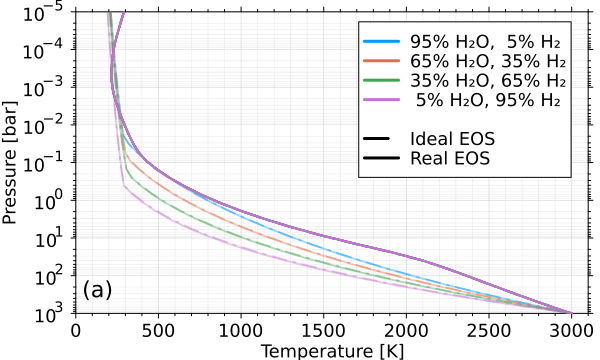

[ WARN  ] No strict ticks found
[ WARN  ] No strict ticks found
[ WARN  ] No strict ticks found
[ WARN  ] No strict ticks found
[ WARN  ] No strict ticks found
[ WARN  ] No strict ticks found
[ WARN  ] No strict ticks found


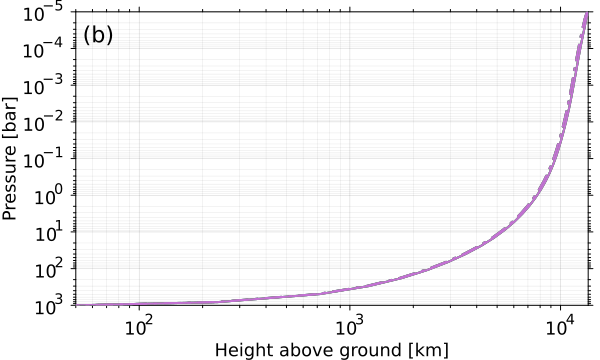

[ WARN  ] No strict ticks found
[ WARN  ] No strict ticks found


"/home/harrison/Projects/AGNI/out/struct_pz.pdf"

In [24]:
fs = 12
figscale = 1.2

arr_P = atmos.pl / 1.0e5 # Convert Pa to bar
ylims  = (arr_P[1], arr_P[end])
yticks = 10.0 .^ round.(Int,range( log10(ylims[1]), stop=log10(ylims[2]), step=1))

props = Dict((
    :size          =>(500*figscale,300*figscale),
    :framestyle    =>:box,
    :tickfontsize  =>fs,
    :guidefontsize =>fs,
    :legendfontsize=>fs,
    :tick_direction=>:out,
    :ylabel => "Pressure [bar]",
))
axl = plot(xlabel="Temperature [K]", legend=:topright; props...)
axr = plot(xlabel="Height above ground [km]"; props...)

z0 = 50.0
function r2z(rl)
    return (rl .- radius) ./ 1e3 .+ z0
end

p = Plots.palette(:default)
lw = 2.0
al = 1.0
ide_sty=:dashdot
rea_sty=:solid
for i in 1:nsamps
    c = p[i]

    # solved
    _lw = lw
    _al = al
    lbl = @sprintf(" %2.0f%% H₂O, %2.0f%% H₂", x_arr[i]*100, (1-x_arr[i])*100)

    # real gas (solid, thick)
    dat = atm_sol_rea[i]
    plot!(axl, dat.tmpl,    dat.pl/1e5, lc=c, alpha=_al, lw=_lw, ls=rea_sty, label=lbl)
    plot!(axr, r2z(dat.rl), dat.pl/1e5, lc=c, alpha=_al, lw=_lw, ls=rea_sty, label="")

    # ideal gas (dashed, thick)
    dat = atm_sol_ide[i]
    plot!(axl, dat.tmpl,    dat.pl/1e5, lc=c, alpha=_al, lw=_lw, ls=ide_sty, label="")
    plot!(axr, r2z(dat.rl), dat.pl/1e5, lc=c, alpha=_al, lw=_lw, ls=ide_sty, label="")

    # adiabatic
    _lw = lw * 0.9
    _al = al * 0.4

    # real gas (solid, thin)
    dat = atm_con_rea[i]
    plot!(axl, dat.tmpl,    dat.pl/1e5, lc=c, alpha=_al, lw=_lw, ls=rea_sty, label="")
    plot!(axr, r2z(dat.rl), dat.pl/1e5, lc=c, alpha=_al, lw=_lw, ls=rea_sty, label="")

    # ideal gas (dashed, thin)
    dat = atm_con_ide[i]
    plot!(axl, dat.tmpl,    dat.pl/1e5, lc=c, alpha=_al, lw=_lw, ls=ide_sty, label="")
    plot!(axr, r2z(dat.rl), dat.pl/1e5, lc=c, alpha=_al, lw=_lw, ls=ide_sty, label="")
end

# legend entries
plot!(axl, [-5, -4], [1, 1], lc=:white, alpha=al, lw=lw, label="  ")
plot!(axl, [-5, -4], [1, 1], lc=:black, alpha=al, lw=lw, ls=ide_sty, label=" Ideal EOS")
plot!(axl, [-5, -4], [1, 1], lc=:black, alpha=al, lw=lw, ls=rea_sty, label=" Real EOS")


# configure axes
for ax in (axl, axr)
    yflip!(ax)
    yaxis!(ax, yscale=:log10,ylims=ylims, yticks=yticks)
end
xlims = (0.0, 3000.0)
dx = 500
xaxis!(axl, minorgrid=true, xlims=(xlims[1], xlims[2]+100), xticks=range(xlims[1], xlims[2], step=dx))
xaxis!(axr, scale=:log10, xlims=(z0, Inf), minorgrid=true, bottom_margin=2Plots.mm)

annotate!(axl, 50,     ylims[2]/2, [text("(a)", :bottom, :left, 15)])
annotate!(axr, z0*1.1, ylims[1]*2, [text("(b)", :top,    :left, 15)])

# show and save plots
display(axl)
savefig(axl, joinpath(output_dir,"struct_pt.pdf"))
display(axr)
savefig(axr, joinpath(output_dir,"struct_pz.pdf"))

In [25]:
for i in 1:nsamps

    lbl = @sprintf("%03d", x_arr[i]*100)

    # real gas (solid, thick)
    dat = atm_sol_rea[i]
    AGNI.save.write_ncdf(dat, joinpath(output_dir, "atm_sol_rea_$lbl.nc"))

    # ideal gas (dashed, thick)
    dat = atm_sol_ide[i]
    AGNI.save.write_ncdf(dat, joinpath(output_dir, "atm_sol_ide_$lbl.nc"))

    # ----------------------

    # real gas (solid, thin)
    dat = atm_con_rea[i]
    AGNI.save.write_ncdf(dat, joinpath(output_dir, "atm_con_rea_$lbl.nc"))

    # ideal gas (dashed, thin)
    dat = atm_con_ide[i]
    AGNI.save.write_ncdf(dat, joinpath(output_dir, "atm_con_ide_$lbl.nc"))

end

println("Done")

Done
